In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x000001C15A9CBFD0>, default_metadata=(), model_kwargs={})

In [3]:
# Step -1 Define the Schema
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List,add_messages] 

In [4]:
#Step 2: Create the node functions
def welcome(state:graph_schema)->graph_schema:

    curr_message = state["messages"]

    response = llm.invoke(curr_message).content

    state["messages"] = f"Your message was {curr_message}. Here's my response: {response}"

    return state

In [5]:
#Step 3: Create the State Graph
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

#Adding Nodes
graph.add_node("Welcome", welcome)

#Adding Edges
graph.add_edge(START, "Welcome")
graph.add_edge("Welcome", END)


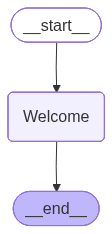

In [ ]:
#Step 4 Compile the graph
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

checkpoint = InMemorySaver()


memory_graph = graph.compile(checkpointer=checkpoint)

Image(memory_graph.get_graph().draw_mermaid_png())

In [7]:
#Step 5 Run the Graph with Config
memory_graph.invoke(
    {"messages": "My name is Adarsh Pandey"},
    {"configurable": {"thread_id": "Adarsh"}}
)

{'messages': [HumanMessage(content='My name is Adarsh Pandey', additional_kwargs={}, response_metadata={}, id='3bdf3aa9-cd69-4137-863e-3f3f239886e1'),
  HumanMessage(content="Your message was [HumanMessage(content='My name is Adarsh Pandey', additional_kwargs={}, response_metadata={}, id='3bdf3aa9-cd69-4137-863e-3f3f239886e1')]. Here's my response: [{'type': 'text', 'text': 'Hello Adarsh Pandey! It’s nice to meet you. How can I help you today?', 'extras': {'signature': 'EtgFCtUFAb4+9vsAhpaM/RX3tcXAtr2myH/4ZpmAjoJDavwe1+9w4MovIgB6YvQqcMUP8vPmrOTd24jJqOLNBqYqKJNCiXFsOLuPZcCn95/VVh0TJ8Dnju+VuUyiOFlsCKLHs8motr4rSTqWkrmYD0dDRHscBHltygOANi9LZBjCWOiCQnZinViF/SIoLWjl7AKthPoyhpMRJJeGZjbfEjchnhkCe1odCzj+ecVd55CDFBkHOms4JO8iAfLfI7faBaqvf7z2FcYNnaI0byVXxvZlpRlZ+vVb9D6pSvjVyl5yBOGVKvKwkn+g188NjamYFQmr/YU12R7ogSr4x12oV1fBg4D5Uaz5jbwLXyEx67hpeTw7sNna1QSR7wbMPXkMJ0eHkfJuOtQGvaBoum3LpW/n8iH8/i9dpQQrcenwkZZXKK2HwG11rfnztqtwSwHTFmsH922EVWqKqZcaJlF4SEolv30d/NL0BEj4uPJFfgsazftJi2psOGLNM4W/SIMwuqMyvEpdXMDz6